In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gpytorch as gp
import torch
from sklearn.gaussian_process.kernels import Matern

np.random.seed(42)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="numpy")


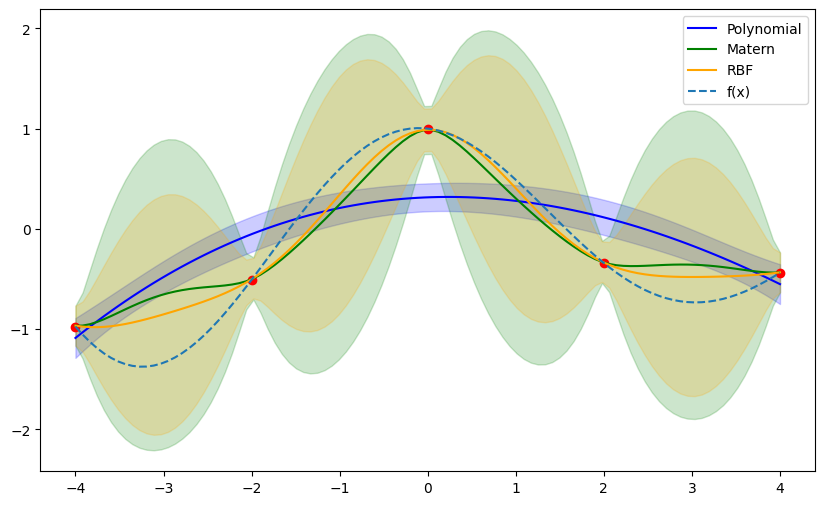

In [ ]:
scale = 1.0
length_scale = 1.0

sigma_n = 0.1
p=3

def get_matern_kernel(scale, length_scale, nu=1.5):
    matern = Matern(length_scale=length_scale, nu=nu)

    def k(x, x_):
        X = np.array([[x]])
        X_ = np.array([[x_]])
        return scale * matern(X, X_)[0, 0]

    return k

def get_rbf_kernel(scale, length_scale):
    return lambda x, x_: scale * np.exp(-0.5 * ((x - x_) / length_scale) ** 2)

def get_polynomial_kernel(sigma_b, sigma_v, p):
    return lambda x, x_: (sigma_b**2 + sigma_v**2 * x * x_)**p


def predict(X_train, y_train, X_test, k):
    n = len(X_train)

    K = np.array([[k(x_i, x_j) for x_j in X_train] for x_i in X_train])
    K += sigma_n**2 * np.eye(n)
    K_inv = np.linalg.inv(K)

    mus = []
    vars = []

    for x in X_test:
        k_star = np.array([k(x_i, x) for x_i in X_train])
        mu = k_star @ K_inv @ y_train

        k_star_T = np.array([k(x, x_i) for x_i in X_train])
        var = k(x, x) - k_star @ K_inv @ k_star_T

        mus.append(mu)
        vars.append(var)

    return np.array(mus), np.array(vars)

# Example
f = lambda x: np.cos(x) * np.exp(-0.1 * x)

X_train = np.linspace(-4, 4, 5)
y_train = f(X_train)
X_test = np.linspace(-4, 4, 100)

# poly
poly_kernel = get_polynomial_kernel(sigma_b=1.0, sigma_v=1.0, p=3)
mus_poly, vars_poly = predict(X_train, y_train, X_test, poly_kernel)

# rbf
rbf_kernel = get_rbf_kernel(scale, length_scale)
mus_rbf, vars_rbf = predict(X_train, y_train, X_test, rbf_kernel)

# matern
matern_kernel = get_matern_kernel(scale, length_scale, nu=1.5)
mus_matern, vars_matern = predict(X_train, y_train, X_test, matern_kernel)

plt.figure(figsize=(10, 6))

plt.plot(X_test, mus_poly, label='Polynomial (p=3)',color='blue')
plt.fill_between(X_test, mus_poly - 2*np.sqrt(vars_poly),
                 mus_poly + 2*np.sqrt(vars_poly), alpha=0.2,color='blue')

plt.plot(X_test, mus_matern, label='Matérn (nu=1.5)', color='green')
plt.fill_between(X_test, mus_matern - 2*np.sqrt(vars_matern), mus_matern + 2*np.sqrt(vars_matern), alpha=0.2, color='green')

plt.plot(X_test, mus_rbf, label='RBF', color='orange')
plt.fill_between(X_test, mus_rbf - 2*np.sqrt(vars_rbf), mus_rbf + 2*np.sqrt(vars_rbf), alpha=0.2, color='orange')

plt.plot(X_test, f(X_test), '--', label='True Function')

plt.scatter(X_train, y_train, color='red')
# plt.title('Gaussian Process Regression with Different Kernels')
plt.legend()
plt.show()

## Matern
